# HomeWork N2

## Decalre libs

In [10]:
!pip install torch-summary

In [11]:
import os
import gc
import json
import random
import numpy as np
from itertools import product
from tqdm.notebook import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict, replace
from sklearn.metrics import jaccard_score, f1_score
from IPython.display import clear_output
from torchsummary import summary
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms


In [12]:
def set_seed(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## Declare first configs

In [13]:
@dataclass
class Config:
    image_size: tuple[int, int] = (128, 128)
    batch_size: int = 32
    epochs: int = 15
    learning_rate: float = 0.0001
    weight_decay: float = 0.0  # 0.0 means AdamW does not add weight-decay regularization
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    train_split: float = 0.8
    model_name: str = "Unet2ConvBlock"
    optimizer_name: str = "AdamW"
    description: str = "U-Net with BCEWithLogitsLoss"

    checkpoint_every: int = 5
    checkpoint_dir: str = "./checkpoints/first_attempt"

    seed: int = 42
    deterministic: bool = True

    num_workers: int = 0  # notebook-safe default; avoids multiprocessing DataLoader cleanup errors
    pin_memory: bool = torch.cuda.is_available()

config = Config()
set_seed(config.seed, config.deterministic)

## Define model Unet

In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output
        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Bottleneck
        b = self.bottleneck(self.pool4(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [15]:
model = UNet().to(config.device)


In [16]:
model_summary = summary(
    model,
    input_size=(3, *config.image_size),  # torch-summary expects channels, height, width
    device=config.device,
)
print(model_summary)


Layer (type:depth-idx)                   Param #
├─DoubleConv: 1-1                        --
|    └─Sequential: 2-1                   --
|    |    └─Conv2d: 3-1                  896
|    |    └─BatchNorm2d: 3-2             64
|    |    └─ReLU: 3-3                    --
|    |    └─Conv2d: 3-4                  9,248
|    |    └─BatchNorm2d: 3-5             64
|    |    └─ReLU: 3-6                    --
├─MaxPool2d: 1-2                         --
├─DoubleConv: 1-3                        --
|    └─Sequential: 2-2                   --
|    |    └─Conv2d: 3-7                  18,496
|    |    └─BatchNorm2d: 3-8             128
|    |    └─ReLU: 3-9                    --
|    |    └─Conv2d: 3-10                 36,928
|    |    └─BatchNorm2d: 3-11            128
|    |    └─ReLU: 3-12                   --
├─MaxPool2d: 1-4                         --
├─DoubleConv: 1-5                        --
|    └─Sequential: 2-3                   --
|    |    └─Conv2d: 3-13                 73,856
|    |   

In [17]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [18]:
investigation_set = PetDataset(root="./data")

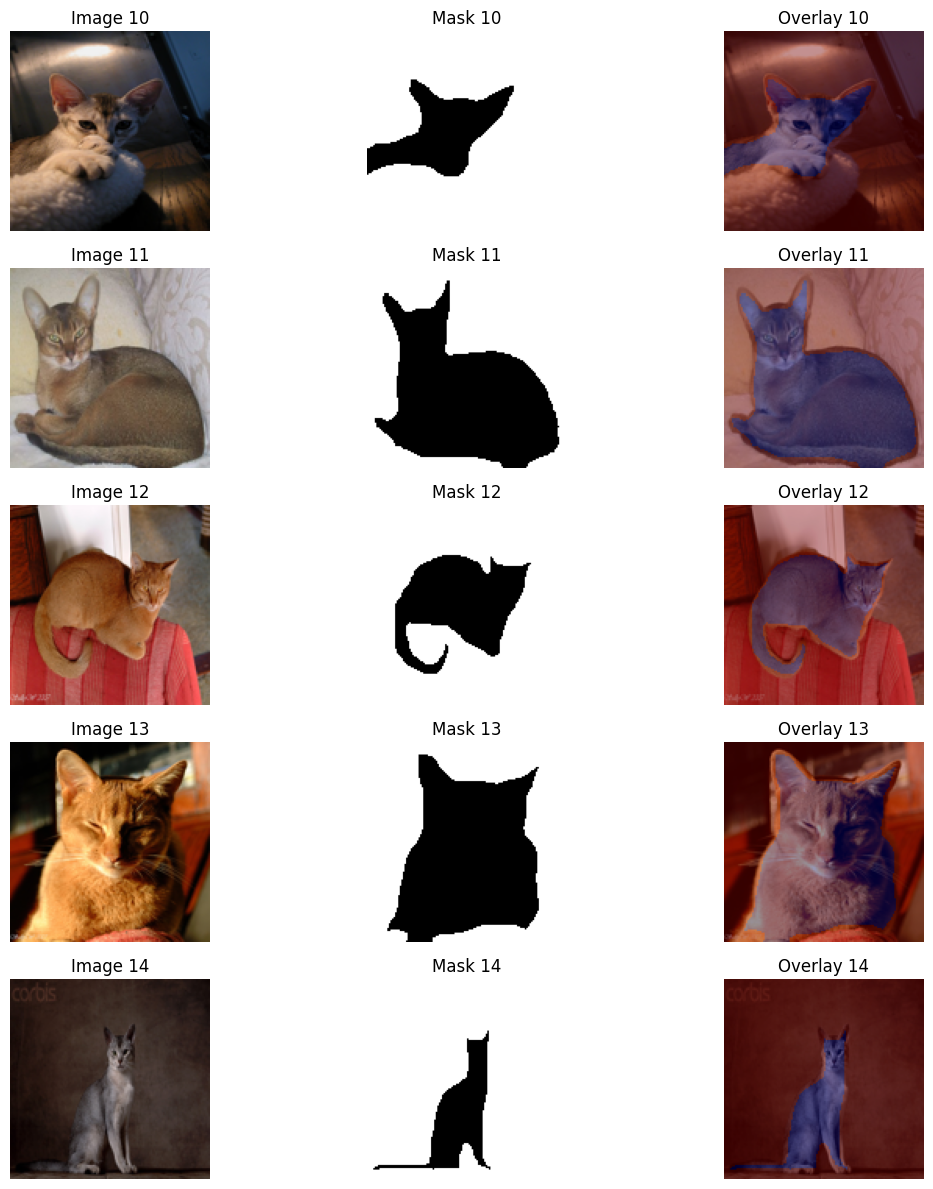

In [19]:
fig, axes = plt.subplots(5, 3, figsize=(12, 12))
# 5 rows, 3 cols

for id_order, id_image in enumerate(range(10, 15)):
    image, mask = investigation_set[id_image]

    # make image and mask same size for display
    img = np.array(image.resize((128, 128)))   # because image is PIL
    msk = mask.squeeze().numpy()

    # image
    axes[id_order, 0].imshow(img)
    axes[id_order, 0].set_title(f"Image {id_image}")
    axes[id_order, 0].axis("off")

    # mask
    axes[id_order, 1].imshow(msk, cmap="gray")
    axes[id_order, 1].set_title(f"Mask {id_image}")
    axes[id_order, 1].axis("off")

    # overlay
    axes[id_order, 2].imshow(img)
    axes[id_order, 2].imshow(msk, cmap="jet", alpha=0.4)
    axes[id_order, 2].set_title(f"Overlay {id_image}")
    axes[id_order, 2].axis("off")

plt.tight_layout()
plt.show()


In [20]:
class Trainer:
    def __init__(self, config, criterion=None):
        self.config = config
        set_seed(self.config.seed, self.config.deterministic)

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.model = self.build_model()
        self.model = self._parallelize_computing(self.model)
        self.model = self.model.to(config.device)
        self.criterion = criterion if criterion is not None else nn.BCEWithLogitsLoss()
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
        )

        os.makedirs(self.config.checkpoint_dir, exist_ok=True)

        self.history = self._create_empty_history()

        self.setup_dataloader()

    def _create_empty_history(self):
        return {
            "epoch": [],
            "train_loss": [],
            "val_loss": [],
            "val_iou": [],
            "val_f1": [],
        }

    def cleanup(self):
        self.train_dataloader = None
        self.val_dataloader = None
        self.test_dataloader = None
        self.test_dataset = None
        self.model = None
        self.optimizer = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def _get_model_state(self):
        if isinstance(self.model, nn.DataParallel):
            return self.model.module.state_dict()
        return self.model.state_dict()

    def _load_model_state(self, state_dict):
        if isinstance(self.model, nn.DataParallel):
            self.model.module.load_state_dict(state_dict)
        else:
            self.model.load_state_dict(state_dict)

    def _get_rng_state(self):
        rng_state = {
            "python": random.getstate(),
            "numpy": np.random.get_state(),
            "torch": torch.get_rng_state(),
        }
        if torch.cuda.is_available():
            rng_state["torch_cuda"] = torch.cuda.get_rng_state_all()
        return rng_state

    def _set_rng_state(self, rng_state):
        if rng_state is None:
            return

        random.setstate(rng_state["python"])
        np.random.set_state(rng_state["numpy"])
        torch.set_rng_state(rng_state["torch"])
        if torch.cuda.is_available() and "torch_cuda" in rng_state:
            torch.cuda.set_rng_state_all(rng_state["torch_cuda"])

    def _parallelize_computing(self, model):
        if torch.cuda.is_available():
            print("GPUs found:", torch.cuda.device_count())
            if torch.cuda.device_count() >= 2:
                return nn.DataParallel(model, device_ids=[0, 1])
            print("only 1 device available")
        else:
            print("cuda unavailable")
        return model

    def build_model(self):
        return UNet()

    def get_latest_checkpoint_path(self):
        return os.path.join(
            self.config.checkpoint_dir,
            f"{self.config.model_name}_latest.pt",
        )

    def get_latest_weights_path(self):
        return os.path.join(
            self.config.checkpoint_dir,
            f"{self.config.model_name}_latest_weights.pt",
        )

    def get_best_weights_path(self):
        return os.path.join(
            self.config.checkpoint_dir,
            f"{self.config.model_name}_best_weights.pt",
        )

    def get_history_path(self):
        return os.path.join(
            self.config.checkpoint_dir,
            f"{self.config.model_name}_history.json",
        )

    def save_online_artifacts(self, best_epoch, best_val_iou, is_best_model=False):
        latest_weights_path = self.get_latest_weights_path()
        torch.save(self._get_model_state(), latest_weights_path)

        history_to_save = {
            "config": asdict(self.config),
            "description": self.config.description,
            "best_epoch": int(best_epoch) if best_epoch is not None else None,
            "best_val_iou": float(best_val_iou) if best_epoch is not None else None,
            "history": {
                "epoch": [int(x) for x in self.history["epoch"]],
                "train_loss": [float(x) for x in self.history["train_loss"]],
                "val_loss": [float(x) for x in self.history["val_loss"]],
                "val_iou": [float(x) for x in self.history["val_iou"]],
                "val_f1": [float(x) for x in self.history["val_f1"]],
            },
        }

        history_path = self.get_history_path()
        with open(history_path, "w") as f:
            json.dump(history_to_save, f, indent=4)

        print(f"Latest weights updated: {latest_weights_path}")
        print(f"Training history updated: {history_path}")

        if is_best_model:
            best_weights_path = self.get_best_weights_path()
            torch.save(self._get_model_state(), best_weights_path)
            print(f"Best weights updated: {best_weights_path}")

    def save_checkpoint(self, epoch, train_loss, val_loss, val_iou, val_f1, best_epoch, best_val_iou):
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": self._get_model_state(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "val_iou": float(val_iou),
            "val_f1": float(val_f1),
            "best_epoch": int(best_epoch) if best_epoch is not None else None,
            "best_val_iou": float(best_val_iou) if best_epoch is not None else None,
            "history": {
                "epoch": [int(x) for x in self.history["epoch"]],
                "train_loss": [float(x) for x in self.history["train_loss"]],
                "val_loss": [float(x) for x in self.history["val_loss"]],
                "val_iou": [float(x) for x in self.history["val_iou"]],
                "val_f1": [float(x) for x in self.history["val_f1"]],
            },
            "rng_state": self._get_rng_state(),
            "config": asdict(self.config),
            "model_name": self.config.model_name,
            "optimizer_name": self.config.optimizer_name,
            "description": self.config.description,
        }

        filename = (
            f"{self.config.model_name}"
            f"_epoch_{epoch}"
            f"_iou_{val_iou:.4f}.pt"
        )
        epoch_path = os.path.join(self.config.checkpoint_dir, filename)
        latest_path = self.get_latest_checkpoint_path()

        torch.save(checkpoint, epoch_path)
        torch.save(checkpoint, latest_path)
        print(f"Checkpoint saved: {epoch_path}")
        print(f"Latest checkpoint updated: {latest_path}")

    def load_latest_checkpoint(self):
        checkpoint_path = self.get_latest_checkpoint_path()
        if not os.path.exists(checkpoint_path):
            print("No checkpoint found. Starting a fresh run.")
            return None

        checkpoint = torch.load(
            checkpoint_path,
            map_location=self.config.device,
            weights_only=False,
        )
        self._load_model_state(checkpoint["model_state_dict"])
        self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        self.history = checkpoint.get("history", self._create_empty_history())
        self._set_rng_state(checkpoint.get("rng_state"))

        resume_state = {
            "start_epoch": int(checkpoint["epoch"]),
            "best_epoch": checkpoint.get("best_epoch"),
            "best_val_iou": checkpoint.get("best_val_iou", float("-inf")),
        }
        print(
            f"Loaded checkpoint: {checkpoint_path}. "
            f"Resuming from epoch {resume_state['start_epoch'] + 1}."
        )
        return resume_state

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split="trainval", transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        split_generator = torch.Generator().manual_seed(self.config.seed)
        train_loader_generator = torch.Generator().manual_seed(self.config.seed + 1)
    
        train_dataset, val_dataset = random_split(
            dataset,
            [train_size, val_size],
            generator=split_generator,
        )
        
        self.test_dataset = PetDataset(root="./data", split="test", transform=self.transform)
        persistent_workers = self.config.num_workers > 0

        self.train_dataloader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
            persistent_workers=persistent_workers,
            worker_init_fn=seed_worker,
            generator=train_loader_generator,
        )
    
        self.val_dataloader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
            persistent_workers=persistent_workers,
            worker_init_fn=seed_worker,
            generator=train_loader_generator,
        )
    
        self.test_dataloader = DataLoader(
            self.test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
            persistent_workers=persistent_workers,
            worker_init_fn=seed_worker,
        )

    def run(self, run_test=True, save_artifacts=True, plot=True, save_checkpoints=True, resume=False, save_online_artifacts=True):
        start_epoch = 0
        best_epoch = None
        best_val_iou = float("-inf")

        if resume:
            resume_state = self.load_latest_checkpoint()
            if resume_state is not None:
                start_epoch = resume_state["start_epoch"]
                best_epoch = resume_state["best_epoch"]
                best_val_iou = resume_state["best_val_iou"]

        for epoch in range(start_epoch, self.config.epochs):
            if plot:
                self.plot_metrics()

            train_loss = self.train(epoch + 1)
            val_loss, val_iou, val_f1 = self.validate(epoch + 1)

            self.history["epoch"].append(epoch + 1)
            self.history["train_loss"].append(float(train_loss))
            self.history["val_loss"].append(float(val_loss))
            self.history["val_iou"].append(float(val_iou))
            self.history["val_f1"].append(float(val_f1))

            is_best_model = val_iou > best_val_iou
            if is_best_model:
                best_val_iou = float(val_iou)
                best_epoch = epoch + 1

            print(
                f"Epoch {epoch + 1} / {self.config.epochs}, "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val IoU: {val_iou:.4f}, "
                f"Val F1-score: {val_f1:.4f}"
            )

            if save_online_artifacts:
                self.save_online_artifacts(
                    best_epoch=best_epoch,
                    best_val_iou=best_val_iou,
                    is_best_model=is_best_model,
                )

            should_save_checkpoint = (
                save_checkpoints
                and ((epoch + 1) % self.config.checkpoint_every == 0 or (epoch + 1) == self.config.epochs)
            )
            if should_save_checkpoint:
                self.save_checkpoint(
                    epoch=epoch + 1,
                    train_loss=train_loss,
                    val_loss=val_loss,
                    val_iou=val_iou,
                    val_f1=val_f1,
                    best_epoch=best_epoch,
                    best_val_iou=best_val_iou,
                )

        if plot:
            self.plot_metrics()

        results = {
            "best_epoch": int(best_epoch) if best_epoch is not None else None,
            "best_val_iou": float(best_val_iou) if best_epoch is not None else None,
            "final_val_loss": float(self.history["val_loss"][-1]) if self.history["val_loss"] else None,
            "final_val_iou": float(self.history["val_iou"][-1]) if self.history["val_iou"] else None,
            "final_val_f1": float(self.history["val_f1"][-1]) if self.history["val_f1"] else None,
        }

        if run_test:
            print("Testing...")
            test_loss, test_iou, test_f1 = self.test()

            print(
                f"Test Loss: {test_loss:.4f}, "
                f"Test IoU: {test_iou:.4f}, "
                f"Test F1-score: {test_f1:.4f}"
            )

            results.update({
                "test_loss": float(test_loss),
                "test_iou": float(test_iou),
                "test_f1": float(test_f1),
            })

            if save_artifacts:
                self.save_final_artifacts(
                    test_loss=test_loss,
                    test_iou=test_iou,
                    test_f1=test_f1,
                )

        return results

    def train(self, epoch=None):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(
            self.train_dataloader,
            desc=f"Train Epoch {epoch}/{self.config.epochs}" if epoch is not None else "Train",
            leave=True,
        ):
            images = images.to(self.config.device, non_blocking=True)
            masks = masks.to(self.config.device, non_blocking=True)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self, epoch=None):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(
                self.val_dataloader,
                desc=f"Val Epoch {epoch}/{self.config.epochs}" if epoch is not None else "Validation",
                leave=True,
            ):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).squeeze(1).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average="binary"))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average="binary"))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(
                self.test_dataloader,
                desc="Test",
                leave=True,
            ):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).squeeze(1).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average="binary"))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average="binary"))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples), squeeze=False)

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype(np.uint8)

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.tight_layout()
            plt.show()

    def save_final_artifacts(self, test_loss, test_iou, test_f1):
        model_name = self.config.model_name

        final_weights_path = os.path.join(
            self.config.checkpoint_dir,
            f"{model_name}_final_weights.pt",
        )
        torch.save(self._get_model_state(), final_weights_path)

        history_to_save = {
            "config": asdict(self.config),
            "description": self.config.description,
            "history": {
                "epoch": [int(x) for x in self.history["epoch"]],
                "train_loss": [float(x) for x in self.history["train_loss"]],
                "val_loss": [float(x) for x in self.history["val_loss"]],
                "val_iou": [float(x) for x in self.history["val_iou"]],
                "val_f1": [float(x) for x in self.history["val_f1"]],
            },
            "test": {
                "test_loss": float(test_loss),
                "test_iou": float(test_iou),
                "test_f1": float(test_f1),
            },
        }

        history_path = self.get_history_path()
        with open(history_path, "w") as f:
            json.dump(history_to_save, f, indent=4)

        full_state_path = os.path.join(
            self.config.checkpoint_dir,
            f"{model_name}_final_full.pt",
        )
        torch.save(
            {
                "model_state_dict": self._get_model_state(),
                "optimizer_state_dict": self.optimizer.state_dict(),
                "config": asdict(self.config),
                "description": self.config.description,
                "history": history_to_save["history"],
                "test": history_to_save["test"],
                "rng_state": self._get_rng_state(),
            },
            full_state_path,
        )

        print(f"Final weights saved: {final_weights_path}")
        print(f"History saved: {history_path}")
        print(f"Full training state saved: {full_state_path}")

    def plot_metrics(self):
        clear_output(wait=True)
        epochs = self.history["epoch"]
        if len(epochs) == 0:
            return

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(epochs, self.history["train_loss"], marker="o", label="Train Loss")
        axes[0].plot(epochs, self.history["val_loss"], marker="o", label="Val Loss")
        axes[0].set_title("Loss per Epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(epochs, self.history["val_iou"], marker="o", label="Val IoU")
        axes[1].plot(epochs, self.history["val_f1"], marker="o", label="Val F1")
        axes[1].set_title("Validation Metrics per Epoch")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Score")
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()
        plt.close(fig)


In [21]:
@dataclass
class HyperparameterSearchConfig:
    search_epochs: int = 5
    learning_rates: tuple[float, ...] = (1e-4, 3e-4, 1e-3)
    batch_sizes: tuple[int, ...] = (16, 32)
    weight_decays: tuple[float, ...] = (0.0, 1e-4, 1e-2)  # 0.0 means no regularization from weight decay (1 - wd * lr) * w - lr * gr
    base_checkpoint_dir: str = "./checkpoints/hparam_search"
    final_checkpoint_dir: str = "./checkpoints/final_model"
    results_filename: str = "search_result.json"
    summary_filename: str = "search_summary.json"


def format_hparam_value(value):
    if isinstance(value, float):
        if value == 0:
            return "0"
        return f"{value:.0e}".replace("+", "")
    return str(value)


def get_trial_name(trial_id, learning_rate, batch_size, weight_decay):
    return (
        f"trial_{trial_id:02d}_"
        f"lr_{format_hparam_value(learning_rate)}_"
        f"bs_{batch_size}_"
        f"wd_{format_hparam_value(weight_decay)}"
    )


def get_trial_result_path(checkpoint_dir, search_config):
    return os.path.join(checkpoint_dir, search_config.results_filename)


def load_saved_trial_result(checkpoint_dir, search_config):
    result_path = get_trial_result_path(checkpoint_dir, search_config)
    if not os.path.exists(result_path):
        return None
    with open(result_path, "r") as f:
        return json.load(f)


def save_trial_result(result, checkpoint_dir, search_config):
    os.makedirs(checkpoint_dir, exist_ok=True)
    result_path = get_trial_result_path(checkpoint_dir, search_config)
    with open(result_path, "w") as f:
        json.dump(result, f, indent=4)


def save_search_summary(completed_results, failed_results, search_config):
    summary_path = os.path.join(search_config.base_checkpoint_dir, search_config.summary_filename)
    with open(summary_path, "w") as f:
        json.dump(
            {
                "completed_trials": completed_results,
                "failed_trials": failed_results,
            },
            f,
            indent=4,
        )


def run_hyperparameter_search(base_config, search_config, resume=True):
    os.makedirs(search_config.base_checkpoint_dir, exist_ok=True)
    all_results = []

    for trial_id, (learning_rate, batch_size, weight_decay) in enumerate(
        product(
            search_config.learning_rates,
            search_config.batch_sizes,
            search_config.weight_decays,
        ),
        start=1,
    ):
        trial_name = get_trial_name(trial_id, learning_rate, batch_size, weight_decay)
        checkpoint_dir = os.path.join(search_config.base_checkpoint_dir, trial_name)
        trial_config = replace(
            base_config,
            epochs=search_config.search_epochs,
            learning_rate=learning_rate,
            batch_size=batch_size,
            weight_decay=weight_decay,
            checkpoint_dir=checkpoint_dir,
            description=(
                f"{base_config.description} | hyperparameter search | "
                f"lr={learning_rate}, batch_size={batch_size}, weight_decay={weight_decay}"
            ),
        )

        saved_result = load_saved_trial_result(checkpoint_dir, search_config)
        if resume and saved_result is not None and saved_result.get("status") == "completed":
            print(
                f"Trial {trial_id} loaded from save: "
                f"lr={learning_rate}, batch_size={batch_size}, weight_decay={weight_decay}, "
                f"best_val_iou={saved_result['best_val_iou']:.4f}"
            )
            all_results.append(saved_result)
            continue

        trial_trainer = None
        try:
            print(
                f"Trial {trial_id}: "
                f"lr={learning_rate}, batch_size={batch_size}, weight_decay={weight_decay}"
            )
            trial_trainer = Trainer(trial_config)
            trial_metrics = trial_trainer.run(
                run_test=False,
                save_artifacts=False,
                plot=False,
                save_checkpoints=False,
            )
            result = {
                "status": "completed",
                "trial_id": trial_id,
                "learning_rate": learning_rate,
                "batch_size": batch_size,
                "weight_decay": weight_decay,
                "best_epoch": trial_metrics["best_epoch"],
                "best_val_iou": trial_metrics["best_val_iou"],
                "final_val_loss": trial_metrics["final_val_loss"],
                "final_val_f1": trial_metrics["final_val_f1"],
                "checkpoint_dir": trial_config.checkpoint_dir,
            }
            save_trial_result(result, checkpoint_dir, search_config)
            all_results.append(result)
        except Exception as error:
            failed_result = {
                "status": "failed",
                "trial_id": trial_id,
                "learning_rate": learning_rate,
                "batch_size": batch_size,
                "weight_decay": weight_decay,
                "checkpoint_dir": trial_config.checkpoint_dir,
                "error": repr(error),
            }
            save_trial_result(failed_result, checkpoint_dir, search_config)
            all_results.append(failed_result)
            print(f"Trial {trial_id} failed and will be retried on the next resume run: {error}")
        finally:
            if trial_trainer is not None:
                trial_trainer.cleanup()
                del trial_trainer
            gc.collect()

    completed_results = [result for result in all_results if result.get("status") == "completed"]
    failed_results = [result for result in all_results if result.get("status") != "completed"]

    if not completed_results:
        raise RuntimeError("No completed hyperparameter trials were found.")

    completed_results = sorted(completed_results, key=lambda item: item["best_val_iou"], reverse=True)
    save_search_summary(completed_results, failed_results, search_config)

    print("\nHyperparameter search results (sorted by best_val_iou):")
    for result in completed_results:
        print(
            f"trial={result['trial_id']:02d} | "
            f"lr={result['learning_rate']} | "
            f"batch_size={result['batch_size']} | "
            f"weight_decay={result['weight_decay']} | "
            f"best_epoch={result['best_epoch']} | "
            f"best_val_iou={result['best_val_iou']:.4f} | "
            f"final_val_loss={result['final_val_loss']:.4f}"
        )

    if failed_results:
        print("\nTrials still failed and can be retried by rerunning the resume cell:")
        for result in failed_results:
            print(
                f"trial={result['trial_id']:02d} | "
                f"lr={result['learning_rate']} | "
                f"batch_size={result['batch_size']} | "
                f"weight_decay={result['weight_decay']} | "
                f"error={result['error']}"
            )

    best_result = completed_results[0]
    best_config = replace(
        base_config,
        learning_rate=best_result["learning_rate"],
        batch_size=best_result["batch_size"],
        weight_decay=best_result["weight_decay"],
        checkpoint_dir=search_config.final_checkpoint_dir,
        description=(
            f"{base_config.description} | tuned by hyperparameter search | "
            f"lr={best_result['learning_rate']}, "
            f"batch_size={best_result['batch_size']}, "
            f"weight_decay={best_result['weight_decay']}"
        ),
    )

    print("\nBest configuration:")
    print(asdict(best_config))

    return completed_results, best_config, failed_results


In [22]:
search_config = HyperparameterSearchConfig(
    search_epochs=5,
    learning_rates=(1e-4, 3e-4, 1e-3),
    batch_sizes=(16, 32),
    weight_decays=(0.0, 1e-4, 1e-2),  # 0.0 means AdamW has no weight-decay regularization
)


In [27]:
import shutil
from pathlib import Path

kaggle_history_source_dir = Path("../input/datasets/jorniklenderlyn2/history-of-hp-search-for-simple-unet/hparam_search")
local_search_dir = Path(search_config.base_checkpoint_dir)

if kaggle_history_source_dir.exists():
    local_search_dir.mkdir(parents=True, exist_ok=True)

    copied_trial_results = 0
    skipped_trial_results = 0

    for source_result_path in kaggle_history_source_dir.rglob(search_config.results_filename):
        relative_parent = source_result_path.parent.relative_to(kaggle_history_source_dir)
        target_trial_dir = local_search_dir / relative_parent
        target_trial_dir.mkdir(parents=True, exist_ok=True)
        target_result_path = target_trial_dir / search_config.results_filename

        if target_result_path.exists():
            skipped_trial_results += 1
            continue

        shutil.copy2(source_result_path, target_result_path)
        copied_trial_results += 1

    source_summary_path = kaggle_history_source_dir / search_config.summary_filename
    target_summary_path = local_search_dir / search_config.summary_filename
    if source_summary_path.exists() and not target_summary_path.exists():
        shutil.copy2(source_summary_path, target_summary_path)

    print(f"Imported {copied_trial_results} trial results from Kaggle history.")
    print(f"Skipped {skipped_trial_results} trial results already present locally.")
else:
    print(f"Kaggle history directory not found: {kaggle_history_source_dir}")

Imported 18 trial results from Kaggle history.
Skipped 0 trial results already present locally.


In [33]:
# Run or resume hyperparameter search.
# Completed trials are loaded from saved JSON files, and only missing/failed trials are retried.
search_results, best_config, failed_search_trials = run_hyperparameter_search(
    config,
    search_config,
    resume=True,
)

print(f"Completed trials: {len(search_results)}")
print(f"Failed trials remaining: {len(failed_search_trials)}")

best_config


Trial 1 loaded from save: lr=0.0001, batch_size=16, weight_decay=0.0, best_val_iou=0.8577
Trial 2 loaded from save: lr=0.0001, batch_size=16, weight_decay=0.0001, best_val_iou=0.8577
Trial 3 loaded from save: lr=0.0001, batch_size=16, weight_decay=0.01, best_val_iou=0.8609
Trial 4 loaded from save: lr=0.0001, batch_size=32, weight_decay=0.0, best_val_iou=0.8503
Trial 5 loaded from save: lr=0.0001, batch_size=32, weight_decay=0.0001, best_val_iou=0.8503
Trial 6 loaded from save: lr=0.0001, batch_size=32, weight_decay=0.01, best_val_iou=0.8486
Trial 7 loaded from save: lr=0.0003, batch_size=16, weight_decay=0.0, best_val_iou=0.8650
Trial 8 loaded from save: lr=0.0003, batch_size=16, weight_decay=0.0001, best_val_iou=0.8644
Trial 9 loaded from save: lr=0.0003, batch_size=16, weight_decay=0.01, best_val_iou=0.8725
Trial 10 loaded from save: lr=0.0003, batch_size=32, weight_decay=0.0, best_val_iou=0.8500
Trial 11 loaded from save: lr=0.0003, batch_size=32, weight_decay=0.0001, best_val_iou=

Config(image_size=(128, 128), batch_size=16, epochs=15, learning_rate=0.0003, weight_decay=0.01, device='cuda', train_split=0.8, model_name='Unet2ConvBlock', optimizer_name='AdamW', description='U-Net with BCEWithLogitsLoss | tuned by hyperparameter search | lr=0.0003, batch_size=16, weight_decay=0.01', checkpoint_every=5, checkpoint_dir='./checkpoints/final_model', seed=42, deterministic=True, num_workers=0, pin_memory=True)

Val Epoch 1/5:   0%|          | 0/46 [00:00<?, ?it/s]

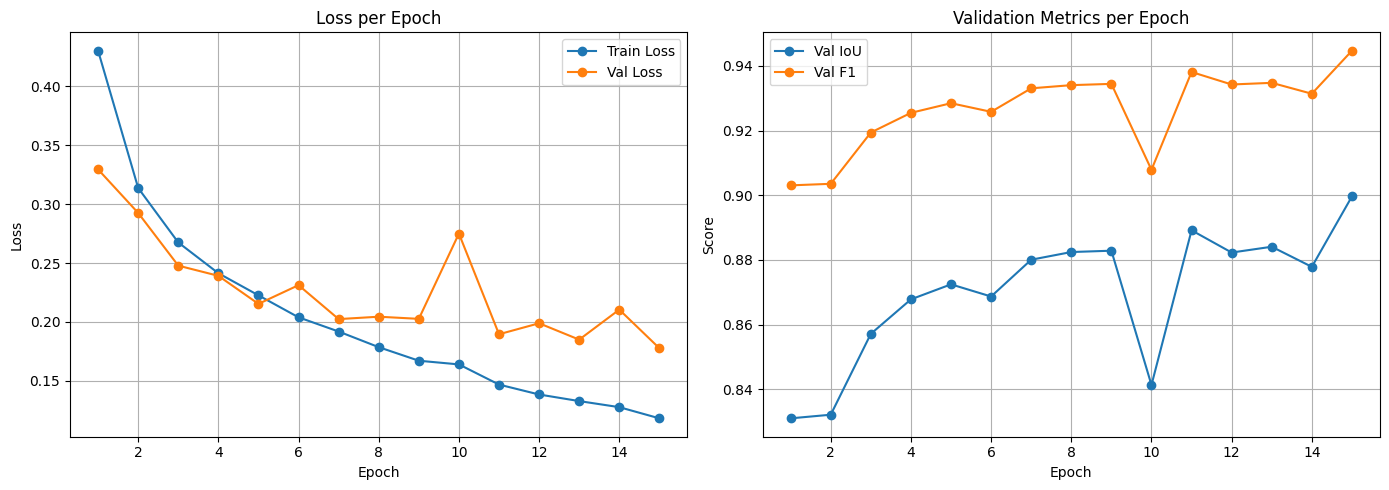

Testing...


Test:   0%|          | 0/230 [00:00<?, ?it/s]

Test Loss: 0.1913, Test IoU: 0.8929, Test F1-score: 0.9397
Final weights saved: ./checkpoints/final_model/Unet2ConvBlock_final_weights.pt
History saved: ./checkpoints/final_model/Unet2ConvBlock_history.json
Full training state saved: ./checkpoints/final_model/Unet2ConvBlock_final_full.pt


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.84313726].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clip

In [ ]:
if failed_search_trials:
    print("Some search trials are still marked as failed. You can rerun the resume-search cell to retry only those trials.")

trainer = Trainer(best_config)
final_metrics = trainer.run()
trainer.inference_and_plot_samples(n_samples=8)

final_metrics


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.84313726].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clip

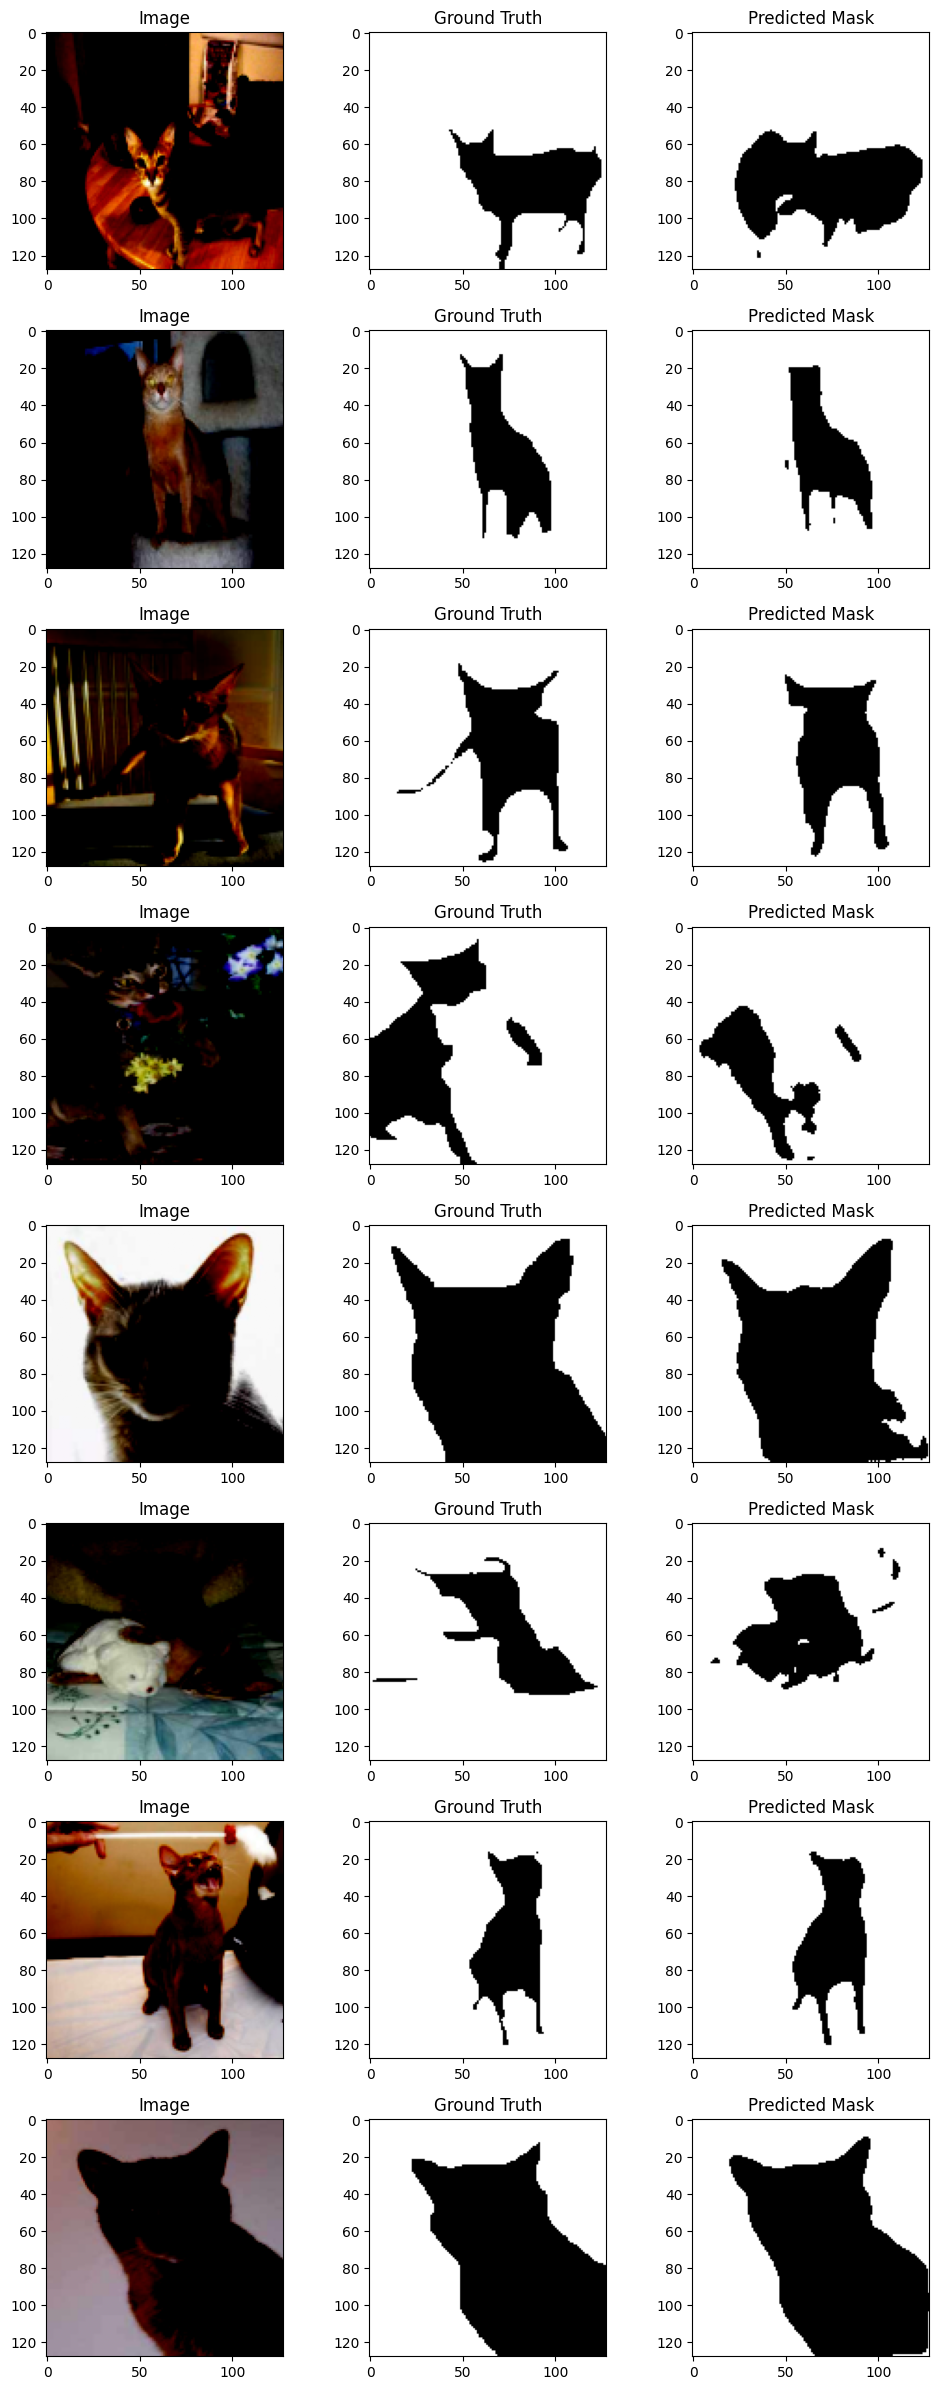

In [35]:
trainer.inference_and_plot_samples(n_samples=8)

In [ ]:
import shutil
shutil.make_archive('hyper_search', 'zip', './checkpoints')

In [36]:
search_hyper_results_df = pd.DataFrame(search_results)
search_hyper_results_df.sort_values('final_val_f1', ascending=False)

,status,trial_id,learning_rate,batch_size,weight_decay,best_epoch,best_val_iou,final_val_loss,final_val_f1,checkpoint_dir
0,completed,9,0.0003,16,0.0100,5,0.872473,0.215313,0.928476,./checkpoints/hparam_search/trial_09_lr_3e-04_...
1,completed,16,0.0010,32,0.0000,5,0.869349,0.221837,0.926517,./checkpoints/hparam_search/trial_16_lr_1e-03_...
2,completed,18,0.0010,32,0.0100,4,0.868262,0.226185,0.925123,./checkpoints/hparam_search/trial_18_lr_1e-03_...
4,completed,8,0.0003,16,0.0001,5,0.864439,0.225263,0.923061,./checkpoints/hparam_search/trial_08_lr_3e-04_...
7,completed,11,0.0003,32,0.0001,5,0.860763,0.246208,0.921219,./checkpoints/hparam_search/trial_11_lr_3e-04_...
6,completed,3,0.0001,16,0.0100,4,0.860940,0.269496,0.916880,./checkpoints/hparam_search/trial_03_lr_1e-04_...
10,completed,15,0.0010,16,0.0100,5,0.853426,0.242862,0.916437,./checkpoints/hparam_search/trial_15_lr_1e-03_...
3,completed,7,0.0003,16,0.0000,4,0.864973,0.242136,0.915920,./checkpoints/hparam_search/trial_07_lr_3e-04_...
12,completed,4,0.0001,32,0.0000,5,0.850297,0.305184,0.914979,./checkpoints/hparam_search/trial_04_lr_1e-04_...
13,completed,5,0.0001,32,0.0001,5,0.850297,0.305184,0.914979,./checkpoints/hparam_search/trial_05_lr_1e-04_...


In [37]:
search_hyper_results_df[search_hyper_results_df['batch_size'] == 16]

,status,trial_id,learning_rate,batch_size,weight_decay,best_epoch,best_val_iou,final_val_loss,final_val_f1,checkpoint_dir
0,completed,9,0.0003,16,0.0100,5,0.872473,0.215313,0.928476,./checkpoints/hparam_search/trial_09_lr_3e-04_...
3,completed,7,0.0003,16,0.0000,4,0.864973,0.242136,0.915920,./checkpoints/hparam_search/trial_07_lr_3e-04_...
4,completed,8,0.0003,16,0.0001,5,0.864439,0.225263,0.923061,./checkpoints/hparam_search/trial_08_lr_3e-04_...
6,completed,3,0.0001,16,0.0100,4,0.860940,0.269496,0.916880,./checkpoints/hparam_search/trial_03_lr_1e-04_...
8,completed,1,0.0001,16,0.0000,4,0.857701,0.279225,0.912377,./checkpoints/hparam_search/trial_01_lr_1e-04_...
9,completed,2,0.0001,16,0.0001,4,0.857701,0.279225,0.912377,./checkpoints/hparam_search/trial_02_lr_1e-04_...
10,completed,15,0.0010,16,0.0100,5,0.853426,0.242862,0.916437,./checkpoints/hparam_search/trial_15_lr_1e-03_...
16,completed,14,0.0010,16,0.0001,4,0.847951,0.248826,0.910155,./checkpoints/hparam_search/trial_14_lr_1e-03_...
17,completed,13,0.0010,16,0.0000,5,0.844678,0.252077,0.910650,./checkpoints/hparam_search/trial_13_lr_1e-03_...


In [38]:
search_hyper_results_df[search_hyper_results_df['batch_size'] == 32]

,status,trial_id,learning_rate,batch_size,weight_decay,best_epoch,best_val_iou,final_val_loss,final_val_f1,checkpoint_dir
1,completed,16,0.0010,32,0.0000,5,0.869349,0.221837,0.926517,./checkpoints/hparam_search/trial_16_lr_1e-03_...
2,completed,18,0.0010,32,0.0100,4,0.868262,0.226185,0.925123,./checkpoints/hparam_search/trial_18_lr_1e-03_...
5,completed,17,0.0010,32,0.0001,4,0.863307,0.264675,0.908369,./checkpoints/hparam_search/trial_17_lr_1e-03_...
7,completed,11,0.0003,32,0.0001,5,0.860763,0.246208,0.921219,./checkpoints/hparam_search/trial_11_lr_3e-04_...
11,completed,12,0.0003,32,0.0100,4,0.851772,0.271473,0.912609,./checkpoints/hparam_search/trial_12_lr_3e-04_...
12,completed,4,0.0001,32,0.0000,5,0.850297,0.305184,0.914979,./checkpoints/hparam_search/trial_04_lr_1e-04_...
13,completed,5,0.0001,32,0.0001,5,0.850297,0.305184,0.914979,./checkpoints/hparam_search/trial_05_lr_1e-04_...
14,completed,10,0.0003,32,0.0000,5,0.849952,0.264813,0.914282,./checkpoints/hparam_search/trial_10_lr_3e-04_...
15,completed,6,0.0001,32,0.0100,3,0.848587,0.317418,0.907771,./checkpoints/hparam_search/trial_06_lr_1e-04_...


In [39]:
search_hyper_results_df[search_hyper_results_df['weight_decay'] == 0]

,status,trial_id,learning_rate,batch_size,weight_decay,best_epoch,best_val_iou,final_val_loss,final_val_f1,checkpoint_dir
1,completed,16,0.0010,32,0.0,5,0.869349,0.221837,0.926517,./checkpoints/hparam_search/trial_16_lr_1e-03_...
3,completed,7,0.0003,16,0.0,4,0.864973,0.242136,0.915920,./checkpoints/hparam_search/trial_07_lr_3e-04_...
8,completed,1,0.0001,16,0.0,4,0.857701,0.279225,0.912377,./checkpoints/hparam_search/trial_01_lr_1e-04_...
12,completed,4,0.0001,32,0.0,5,0.850297,0.305184,0.914979,./checkpoints/hparam_search/trial_04_lr_1e-04_...
14,completed,10,0.0003,32,0.0,5,0.849952,0.264813,0.914282,./checkpoints/hparam_search/trial_10_lr_3e-04_...
17,completed,13,0.0010,16,0.0,5,0.844678,0.252077,0.910650,./checkpoints/hparam_search/trial_13_lr_1e-03_...


In [40]:
search_hyper_results_df[search_hyper_results_df['weight_decay'] == 0.0001]

,status,trial_id,learning_rate,batch_size,weight_decay,best_epoch,best_val_iou,final_val_loss,final_val_f1,checkpoint_dir
4,completed,8,0.0003,16,0.0001,5,0.864439,0.225263,0.923061,./checkpoints/hparam_search/trial_08_lr_3e-04_...
5,completed,17,0.0010,32,0.0001,4,0.863307,0.264675,0.908369,./checkpoints/hparam_search/trial_17_lr_1e-03_...
7,completed,11,0.0003,32,0.0001,5,0.860763,0.246208,0.921219,./checkpoints/hparam_search/trial_11_lr_3e-04_...
9,completed,2,0.0001,16,0.0001,4,0.857701,0.279225,0.912377,./checkpoints/hparam_search/trial_02_lr_1e-04_...
13,completed,5,0.0001,32,0.0001,5,0.850297,0.305184,0.914979,./checkpoints/hparam_search/trial_05_lr_1e-04_...
16,completed,14,0.0010,16,0.0001,4,0.847951,0.248826,0.910155,./checkpoints/hparam_search/trial_14_lr_1e-03_...


Комбинация гиперпараметров **(lr=0.0003, batch_sz=16 wd=0.0100)** занимает **первое** место, даже после смены random seed место этой комбинации в лидерборде не изменилось.
Гиперпараметры на первой позиции дали лучший результат (*F1=0.928*) потому что веса обновлялись в 2 раза чаще за эпоху чем у остальных топ 3 места, при этом шаг в 3 раза меньше чем у топ 3 экспериментов, поэтому при частом изменении мы сильно не сбиваемся с пути к минимуму, также используется регуляризация весов, которая происходить на шаг оптимизатора

2е и 3е место используют lr больше чем top1 (*lr=0.0010 >  lr=0.0003*) но при этом у них больше батч, что позволяет делать больший шаг в более точном направлении, также эти два места почти не используют регуляризацию посравнению с top1, вероятно это из за того что веса обновляются в 2 раза реже, что требует дольше обучать модель при использовании регуляризации (на 4ом месте комбинация с явной регуляризацией и батчем *batch_sz=16*)

#### Модель
Модель мне кажется слабоватой, 7м параметров, поэтому в следующем эксперименте выберу модель с основой на resnet34 21м параметров
перебор параметров буду делать при помощи optuna для ускорения процесса
в качестве лосса буду использовать BinaryCrossEntropy + Dice

## Additional experiment: ResNet34 segmentation with Dice + BCE and Optuna

In [49]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [50]:
import optuna
import torchvision.models as tv_models

In [61]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip=None):
        x = nn.functional.interpolate(
            x,
            scale_factor=2,
            mode="bilinear",
            align_corners=False,
        )
        if skip is not None:
            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(
                    x,
                    size=skip.shape[-2:],
                    mode="bilinear",
                    align_corners=False,
                )
            x = torch.cat([x, skip], dim=1)
        return self.block(x)

class ResNet34UNet(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()
        try:
            encoder = tv_models.resnet34(weights=None)
        except TypeError:
            encoder = tv_models.resnet34(pretrained=False)

        self.stem = nn.Sequential(
            encoder.conv1,
            encoder.bn1,
            encoder.relu,
        )
        self.pool = encoder.maxpool
        self.layer1 = encoder.layer1
        self.layer2 = encoder.layer2
        self.layer3 = encoder.layer3
        self.layer4 = encoder.layer4

        self.bridge = DoubleConv(512, 512)
        self.dec4 = DecoderBlock(512 + 256, 256)
        self.dec3 = DecoderBlock(256 + 128, 128)
        self.dec2 = DecoderBlock(128 + 64, 64)
        self.dec1 = DecoderBlock(64 + 64, 64)
        self.dec0 = DecoderBlock(64, 32)
        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x0 = self.stem(x)
        x1 = self.layer1(self.pool(x0))
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        x = self.bridge(x4)
        x = self.dec4(x, x3)
        x = self.dec3(x, x2)
        x = self.dec2(x, x1)
        x = self.dec1(x, x0)
        x = self.dec0(x)
        return self.out_conv(x)


class ResNet34ExperimentTrainer(Trainer):
    def build_model(self):
        return ResNet34UNet()

In [62]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probabilities = torch.sigmoid(logits)
        targets = targets.float()

        probabilities = probabilities.view(probabilities.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probabilities * targets).sum(dim=1)
        dice_score = (2.0 * intersection + self.smooth) / (
            probabilities.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        return 1.0 - dice_score.mean()


class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5, smooth=1.0):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.dice_loss = DiceLoss(smooth=smooth)
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        dice = self.dice_loss(logits, targets)
        bce = self.bce_loss(logits, targets)
        return self.dice_weight * dice + self.bce_weight * bce

In [63]:
@dataclass
class ResNet34ExperimentConfig(Config):
    model_name: str = "ResNet34UNet"
    description: str = "ResNet34 encoder-decoder with Dice + BCE"
    checkpoint_every: int = 1
    checkpoint_dir: str = "./checkpoints/final_model_resnet34_dice_bce"
    seed: int = 42


resnet34_dice_bce_n_trials = 10
resnet34_dice_bce_search_epochs = 5
resnet34_dice_bce_batch_sizes = (16, 32)
resnet34_dice_bce_weight_decays = (0.0, 1e-5, 1e-4, 1e-3, 1e-2)
resnet34_dice_bce_study_name = "resnet34_dice_bce_optuna"
resnet34_dice_bce_search_checkpoint_dir = "./checkpoints/optuna_resnet34_dice_bce"

In [64]:
def build_dice_bce_criterion():
    return DiceBCELoss(dice_weight=0.5, bce_weight=0.5)


def run_optuna_resnet34_dice_bce_experiment(
    base_config,
    n_trials=10,
    search_epochs=5,
    batch_sizes=(16, 32),
    weight_decays=(0.0, 1e-5, 1e-4, 1e-3, 1e-2),
    study_name="resnet34_dice_bce_optuna",
    search_checkpoint_dir="./checkpoints/optuna_resnet34_dice_bce",
    final_checkpoint_dir="./checkpoints/final_model_resnet34_dice_bce",
):
    os.makedirs(search_checkpoint_dir, exist_ok=True)
    storage_path = os.path.abspath(
        os.path.join(search_checkpoint_dir, "optuna_study.db")
    )
    study = optuna.create_study(
        direction="maximize",
        study_name=study_name,
        storage=f"sqlite:///{storage_path}",
        load_if_exists=True,
        sampler=optuna.samplers.TPESampler(seed=base_config.seed),
    )

    completed_trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
    ]
    remaining_trials = max(0, n_trials - len(completed_trials))

    print(f"Completed Optuna trials found: {len(completed_trials)}")
    print(f"Remaining Optuna trials to run: {remaining_trials}")

    def get_trial_result_path(trial_number):
        return os.path.join(
            search_checkpoint_dir,
            f"trial_{trial_number:03d}_result.json",
        )

    def load_trial_result(trial_number):
        trial_result_path = get_trial_result_path(trial_number)
        if not os.path.exists(trial_result_path):
            return None
        with open(trial_result_path, "r") as f:
            return json.load(f)

    def save_trial_result(trial_number, result):
        trial_result_path = get_trial_result_path(trial_number)
        with open(trial_result_path, "w") as f:
            json.dump(result, f, indent=4)

    def objective(trial):
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", list(batch_sizes))
        weight_decay = trial.suggest_categorical("weight_decay", list(weight_decays))
        trial_config = replace(
            base_config,
            epochs=search_epochs,
            learning_rate=learning_rate,
            batch_size=batch_size,
            weight_decay=weight_decay,
            checkpoint_dir=search_checkpoint_dir,
            model_name="ResNet34UNet",
            description=(
                "ResNet34 encoder-decoder with Dice + BCE | Optuna trial | "
                f"lr={learning_rate}, batch_size={batch_size}, weight_decay={weight_decay}"
            ),
        )

        saved_trial_result = load_trial_result(trial.number)
        if saved_trial_result is not None and saved_trial_result.get("status") == "completed":
            print(
                f"Trial {trial.number} loaded from checkpoint: "
                f"best_val_iou={saved_trial_result['best_val_iou']:.4f}"
            )
            trial.set_user_attr("best_epoch", saved_trial_result["best_epoch"])
            trial.set_user_attr("final_val_loss", saved_trial_result["final_val_loss"])
            trial.set_user_attr("final_val_f1", saved_trial_result["final_val_f1"])
            return saved_trial_result["best_val_iou"]

        trial_trainer = None
        try:
            trial_trainer = ResNet34ExperimentTrainer(
                trial_config,
                criterion=build_dice_bce_criterion(),
            )
            trial_metrics = trial_trainer.run(
                run_test=False,
                save_artifacts=False,
                plot=False,
                save_checkpoints=False,
                resume=False,
                save_online_artifacts=False,
            )
            trial_result = {
                "status": "completed",
                "trial_number": trial.number,
                "config": asdict(trial_config),
                "learning_rate": learning_rate,
                "batch_size": batch_size,
                "weight_decay": weight_decay,
                "best_epoch": trial_metrics["best_epoch"],
                "best_val_iou": trial_metrics["best_val_iou"],
                "final_val_loss": trial_metrics["final_val_loss"],
                "final_val_f1": trial_metrics["final_val_f1"],
            }
            save_trial_result(trial.number, trial_result)
            trial.set_user_attr("best_epoch", trial_metrics["best_epoch"])
            trial.set_user_attr("final_val_loss", trial_metrics["final_val_loss"])
            trial.set_user_attr("final_val_f1", trial_metrics["final_val_f1"])
            return trial_metrics["best_val_iou"]
        finally:
            if trial_trainer is not None:
                trial_trainer.cleanup()
                del trial_trainer
            gc.collect()

    if remaining_trials > 0:
        study.optimize(
            objective,
            n_trials=remaining_trials,
            gc_after_trial=True,
        )

    best_resnet34_config = replace(
        base_config,
        learning_rate=study.best_params["learning_rate"],
        batch_size=study.best_params["batch_size"],
        weight_decay=study.best_params["weight_decay"],
        checkpoint_dir=final_checkpoint_dir,
        model_name="ResNet34UNet",
        description=(
            "ResNet34 encoder-decoder with Dice + BCE | tuned by Optuna | "
            f"lr={study.best_params['learning_rate']}, "
            f"batch_size={study.best_params['batch_size']}, "
            f"weight_decay={study.best_params['weight_decay']}"
        ),
    )

    resnet34_trials_df = study.trials_dataframe(
        attrs=("number", "value", "params", "state", "user_attrs")
    )

    print("Best ResNet34 Dice + BCE trial:")
    print(study.best_trial)
    print("Best ResNet34 Dice + BCE config:")
    print(asdict(best_resnet34_config))

    return study, best_resnet34_config, resnet34_trials_df

In [65]:
resnet34_dice_bce_base_config = ResNet34ExperimentConfig()

resnet34_dice_bce_study, resnet34_dice_bce_best_config, resnet34_dice_bce_trials_df = run_optuna_resnet34_dice_bce_experiment(
    resnet34_dice_bce_base_config,
    n_trials=resnet34_dice_bce_n_trials,
    search_epochs=resnet34_dice_bce_search_epochs,
    batch_sizes=resnet34_dice_bce_batch_sizes,
    weight_decays=resnet34_dice_bce_weight_decays,
    study_name=resnet34_dice_bce_study_name,
    search_checkpoint_dir=resnet34_dice_bce_search_checkpoint_dir,
    final_checkpoint_dir=resnet34_dice_bce_base_config.checkpoint_dir,
)

resnet34_dice_bce_trials_df.sort_values("value", ascending=False)

[I 2026-04-22 22:25:14,249] Using an existing study with name 'resnet34_dice_bce_optuna' instead of creating a new one.


Completed Optuna trials found: 10
Remaining Optuna trials to run: 0
Best ResNet34 Dice + BCE trial:
FrozenTrial(number=3, state=<TrialState.COMPLETE: 1>, values=[0.83238642981944], datetime_start=datetime.datetime(2026, 4, 22, 16, 46, 39, 456391), datetime_complete=datetime.datetime(2026, 4, 22, 16, 50, 24, 901869), params={'learning_rate': 8.168455894760161e-05, 'batch_size': 16, 'weight_decay': 0.001}, user_attrs={'best_epoch': 5, 'final_val_f1': 0.903475993453985, 'final_val_loss': 0.23138750117758047}, system_attrs={}, intermediate_values={}, distributions={'learning_rate': FloatDistribution(high=0.001, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(16, 32)), 'weight_decay': CategoricalDistribution(choices=(0.0, 1e-05, 0.0001, 0.001, 0.01))}, trial_id=4, value=None)
Best ResNet34 Dice + BCE config:
{'image_size': (128, 128), 'batch_size': 16, 'epochs': 15, 'learning_rate': 8.168455894760161e-05, 'weight_decay': 0.001, 'device': 'cuda', 'train_split'

,number,value,params_batch_size,params_learning_rate,params_weight_decay,state,user_attrs_best_epoch,user_attrs_final_val_f1,user_attrs_final_val_loss
3,3,0.832386,16,0.000082,0.00100,COMPLETE,5,0.903476,0.231388
6,6,0.832384,32,0.000124,0.00001,COMPLETE,5,0.903800,0.236811
0,0,0.826300,16,0.000056,0.01000,COMPLETE,5,0.899470,0.247830
1,1,0.824232,16,0.000159,0.00000,COMPLETE,5,0.898188,0.227366
8,8,0.816157,16,0.000036,0.00010,COMPLETE,5,0.893233,0.272129
2,2,0.812856,16,0.000041,0.00001,COMPLETE,5,0.891221,0.267446
7,7,0.787232,16,0.000015,0.00100,COMPLETE,5,0.874850,0.315354
5,5,0.778219,16,0.000018,0.00000,COMPLETE,5,0.868803,0.313777
9,9,0.777119,16,0.000010,0.00001,COMPLETE,5,0.868568,0.331734
4,4,0.771909,32,0.000013,0.00000,COMPLETE,5,0.865462,0.342867


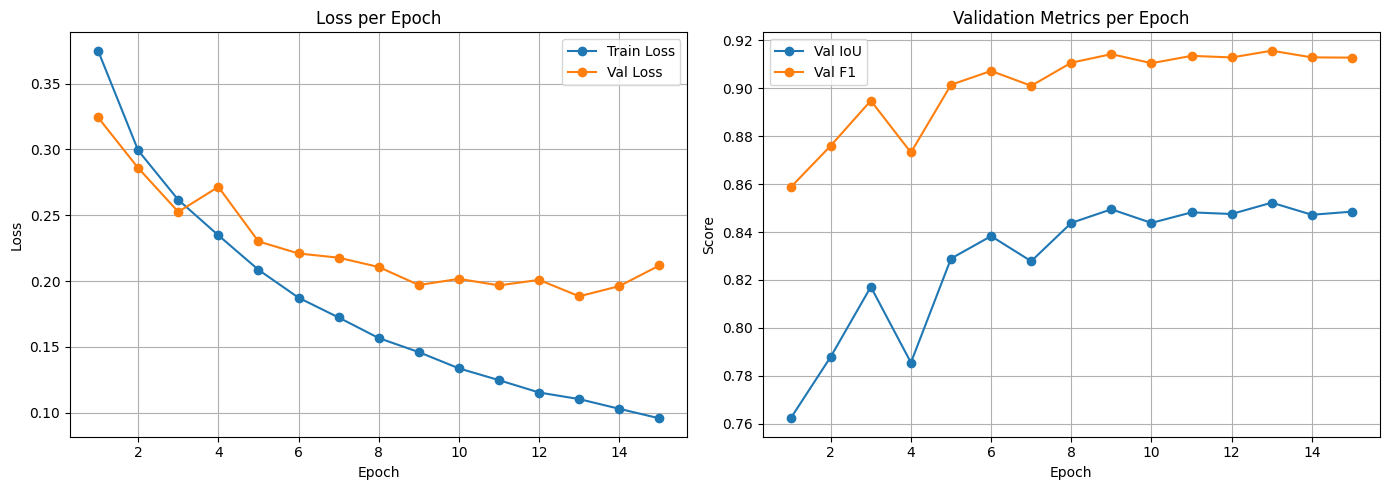

Testing...


Test:   0%|          | 0/230 [00:00<?, ?it/s]

Test Loss: 0.2159, Test IoU: 0.8452, Test F1-score: 0.9096
Final weights saved: ./checkpoints/final_model_resnet34_dice_bce/ResNet34UNet_final_weights.pt
History saved: ./checkpoints/final_model_resnet34_dice_bce/ResNet34UNet_history.json
Full training state saved: ./checkpoints/final_model_resnet34_dice_bce/ResNet34UNet_final_full.pt


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.84313726].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clip

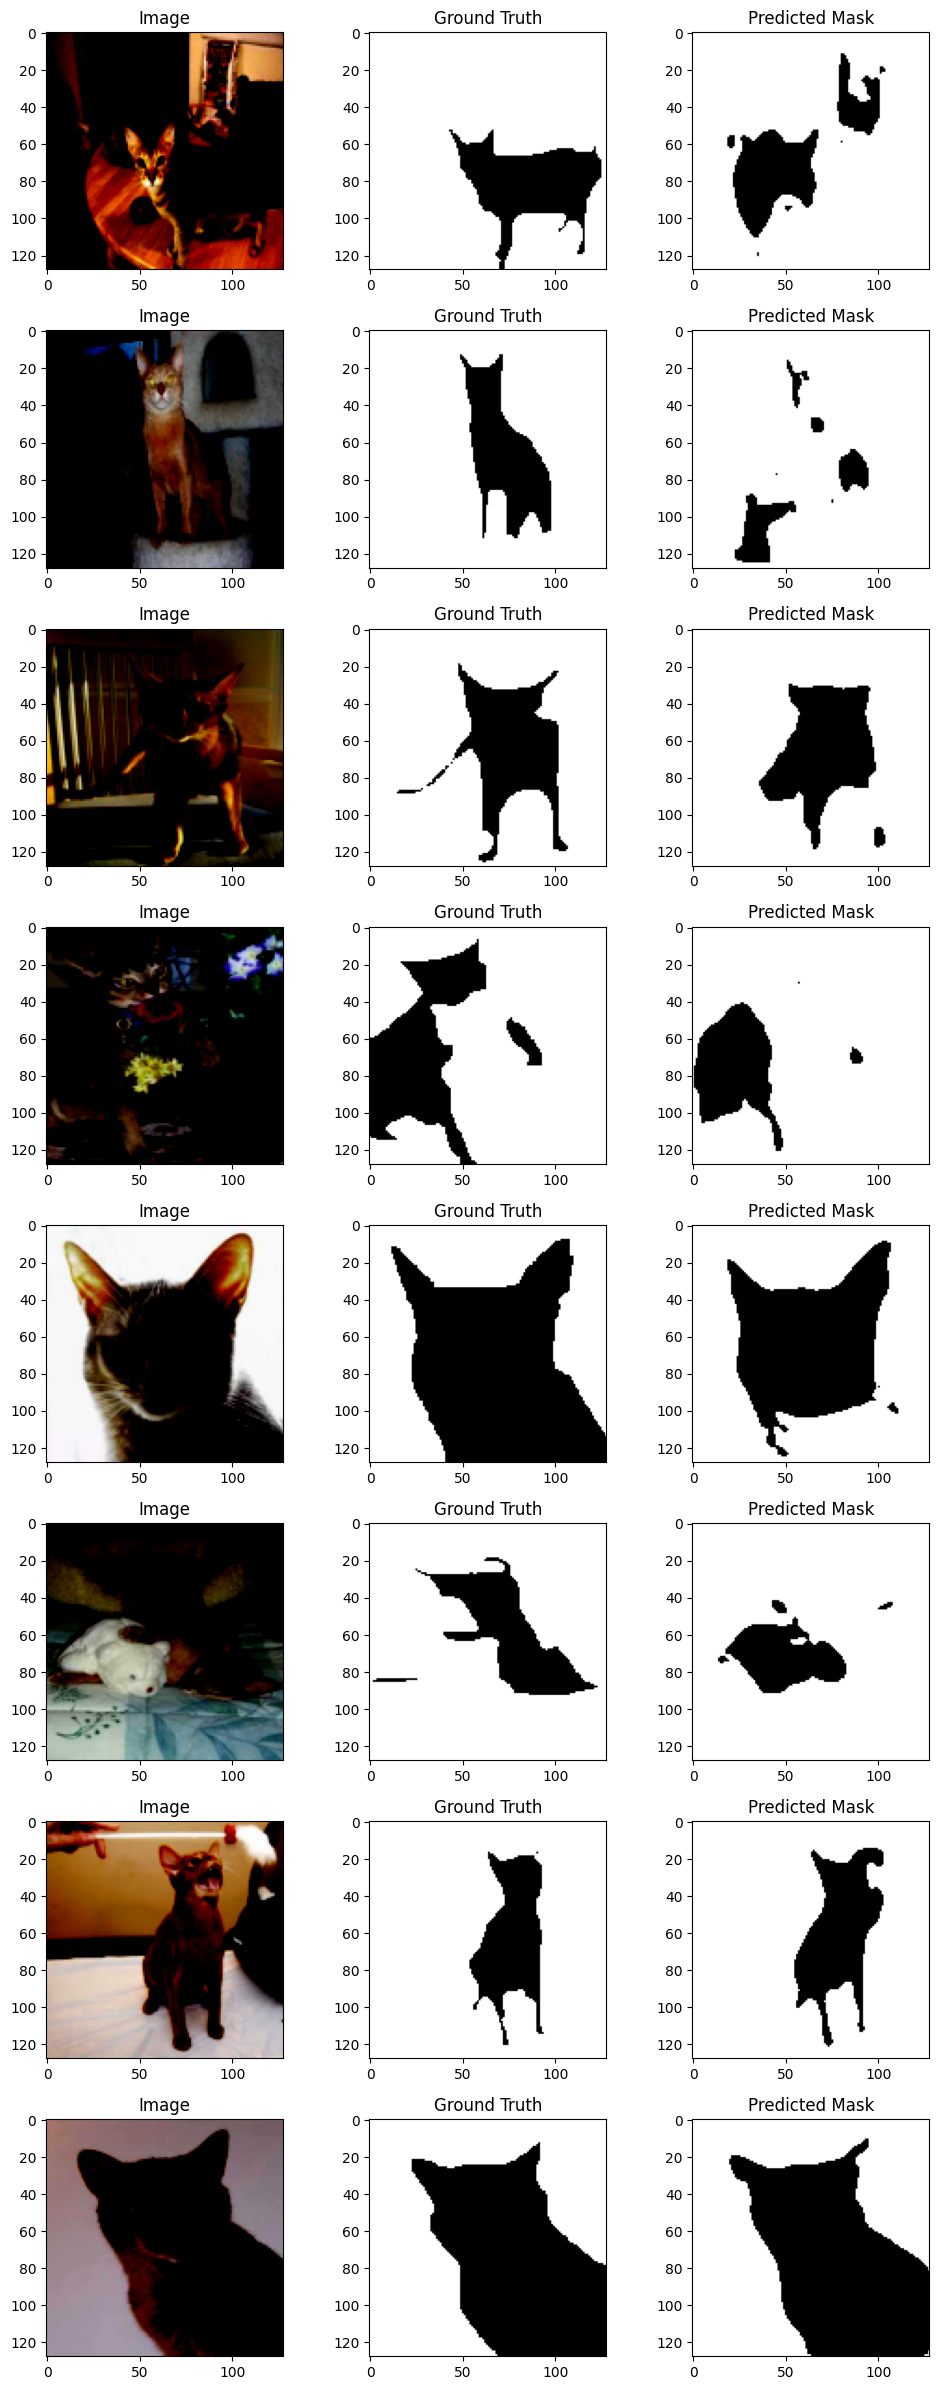

{'best_epoch': 13,
 'best_val_iou': 0.8522653885593894,
 'final_val_loss': 0.2118975478021995,
 'final_val_iou': 0.8485051149675135,
 'final_val_f1': 0.9127658830807346,
 'test_loss': 0.2159061245944189,
 'test_iou': 0.8452205946349405,
 'test_f1': 0.9096239813210172}

In [70]:
resnet34_dice_bce_trainer = ResNet34ExperimentTrainer(
    resnet34_dice_bce_best_config,
    criterion=build_dice_bce_criterion(),
)
resnet34_dice_bce_final_metrics = resnet34_dice_bce_trainer.run(
    save_checkpoints=True,
    resume=True,
)
resnet34_dice_bce_trainer.inference_and_plot_samples(n_samples=8)

resnet34_dice_bce_final_metrics

In [71]:
def build_pretrained_resnet34_encoder():
    try:
        return tv_models.resnet34(weights=tv_models.ResNet34_Weights.DEFAULT)
    except AttributeError:
        return tv_models.resnet34(pretrained=True)


class PretrainedResNet34UNet(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()
        encoder = build_pretrained_resnet34_encoder()

        self.stem = nn.Sequential(
            encoder.conv1,
            encoder.bn1,
            encoder.relu,
        )
        self.pool = encoder.maxpool
        self.layer1 = encoder.layer1
        self.layer2 = encoder.layer2
        self.layer3 = encoder.layer3
        self.layer4 = encoder.layer4

        self.bridge = DoubleConv(512, 512)
        self.dec4 = DecoderBlock(512 + 256, 256)
        self.dec3 = DecoderBlock(256 + 128, 128)
        self.dec2 = DecoderBlock(128 + 64, 64)
        self.dec1 = DecoderBlock(64 + 64, 64)
        self.dec0 = DecoderBlock(64, 32)
        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x0 = self.stem(x)
        x1 = self.layer1(self.pool(x0))
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        x = self.bridge(x4)
        x = self.dec4(x, x3)
        x = self.dec3(x, x2)
        x = self.dec2(x, x1)
        x = self.dec1(x, x0)
        x = self.dec0(x)
        return self.out_conv(x)


class PretrainedResNet34ExperimentTrainer(Trainer):
    def build_model(self):
        return PretrainedResNet34UNet()


@dataclass
class PretrainedResNet34ExperimentConfig(Config):
    model_name: str = "PretrainedResNet34UNet"
    description: str = "Pretrained ResNet34 encoder-decoder with Dice + BCE"
    checkpoint_dir: str = "./checkpoints/final_model_pretrained_resnet34_dice_bce"

In [72]:
pretrained_resnet34_config = PretrainedResNet34ExperimentConfig(
    **{
        **asdict(resnet34_dice_bce_best_config),
        "model_name": "PretrainedResNet34UNet",
        "description": "Pretrained ResNet34 encoder-decoder with Dice + BCE | best config from non-pretrained ResNet34",
        "checkpoint_dir": "./checkpoints/final_model_pretrained_resnet34_dice_bce",
    }
)

pretrained_resnet34_config

PretrainedResNet34ExperimentConfig(image_size=(128, 128), batch_size=16, epochs=15, learning_rate=8.168455894760161e-05, weight_decay=0.001, device='cuda', train_split=0.8, model_name='PretrainedResNet34UNet', optimizer_name='AdamW', description='Pretrained ResNet34 encoder-decoder with Dice + BCE | best config from non-pretrained ResNet34', checkpoint_every=1, checkpoint_dir='./checkpoints/final_model_pretrained_resnet34_dice_bce', seed=42, deterministic=True, num_workers=0, pin_memory=True)

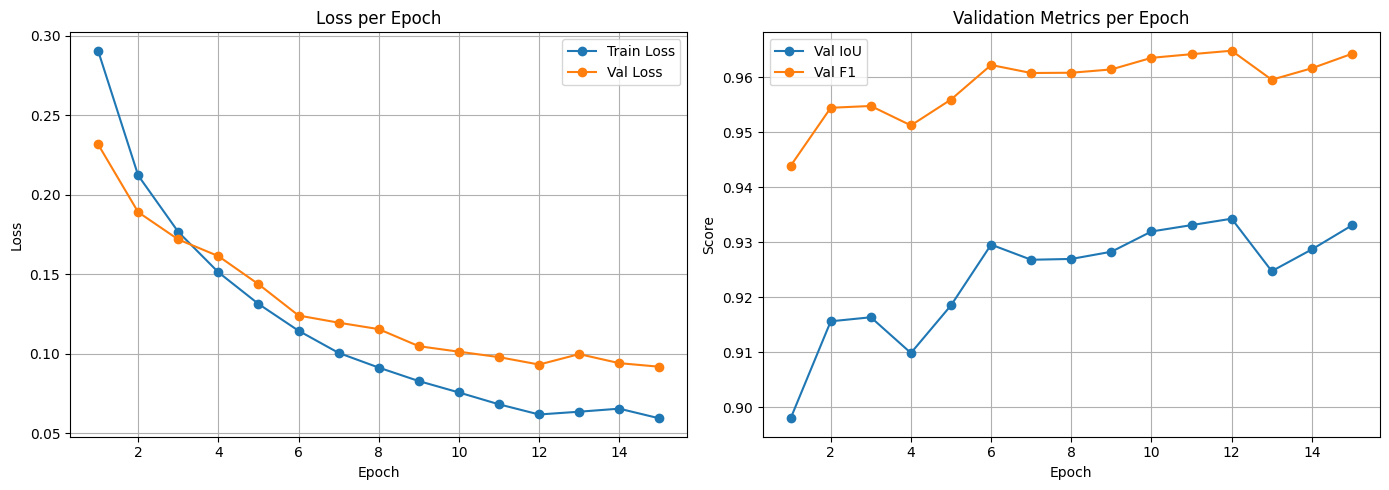

Testing...


Test:   0%|          | 0/230 [00:00<?, ?it/s]

Test Loss: 0.1024, Test IoU: 0.9251, Test F1-score: 0.9587


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].


Final weights saved: ./checkpoints/final_model_pretrained_resnet34_dice_bce/PretrainedResNet34UNet_final_weights.pt
History saved: ./checkpoints/final_model_pretrained_resnet34_dice_bce/PretrainedResNet34UNet_history.json
Full training state saved: ./checkpoints/final_model_pretrained_resnet34_dice_bce/PretrainedResNet34UNet_final_full.pt


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.84313726].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6784314]

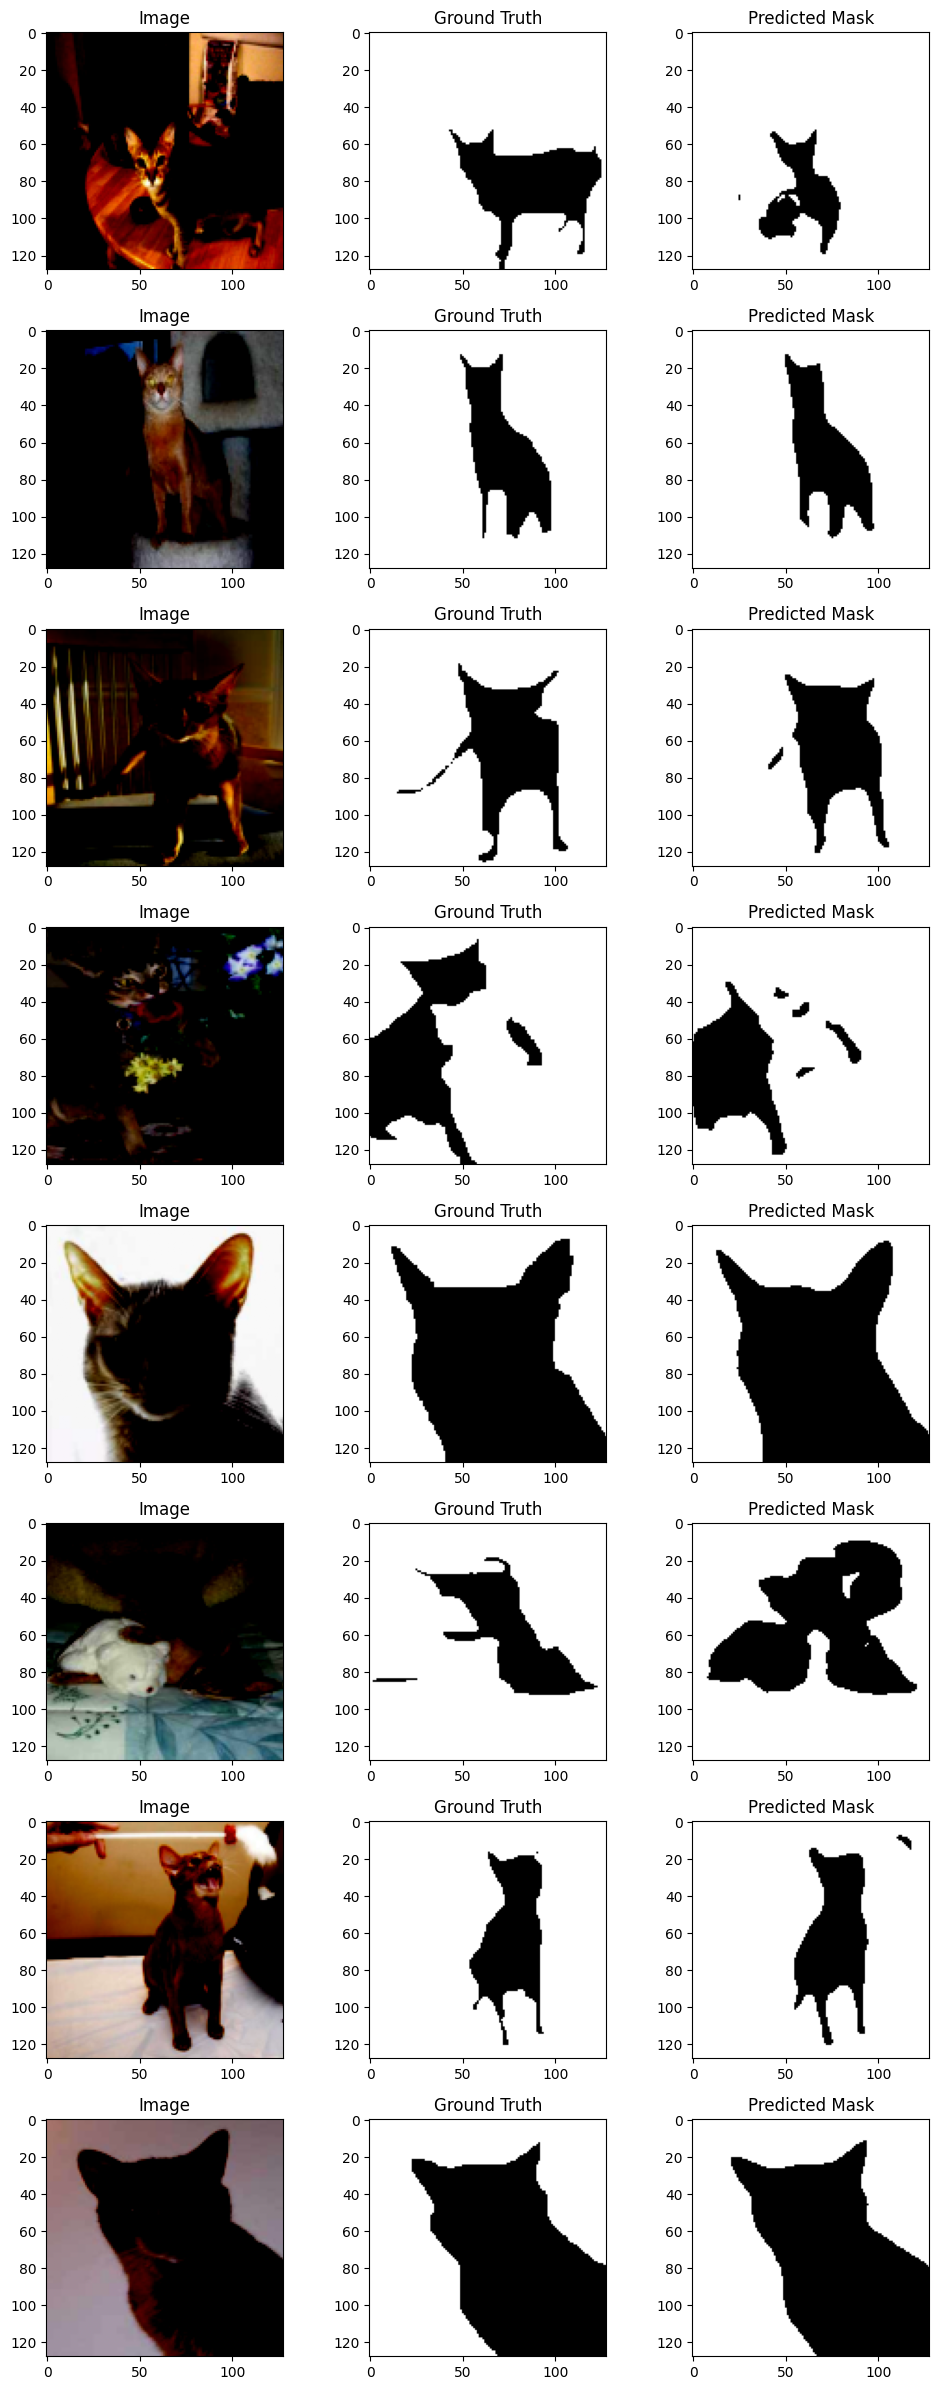

{'best_epoch': 12,
 'best_val_iou': 0.9342540092668,
 'final_val_loss': 0.09189190699354462,
 'final_val_iou': 0.933040062213203,
 'final_val_f1': 0.96422017677621,
 'test_loss': 0.10242756878876168,
 'test_iou': 0.9251437814161958,
 'test_f1': 0.9587084827197444}

In [73]:
pretrained_resnet34_trainer = PretrainedResNet34ExperimentTrainer(
    pretrained_resnet34_config,
    criterion=build_dice_bce_criterion(),
)
pretrained_resnet34_final_metrics = pretrained_resnet34_trainer.run(
    save_checkpoints=True,
    resume=True,
)
pretrained_resnet34_trainer.inference_and_plot_samples(n_samples=8)

pretrained_resnet34_final_metrics